# Model Architecture Analysis

Comprehensive analysis of all tested model architectures for the DGL 2026 Brain Graph Super-Resolution Challenge.

**Quick Generalization Heuristic:** Val loss alone is misleading (e.g. DenseGCN-CA had val loss 0.12 but Kaggle 0.476). Use **PCC** and **Strength MAE** during CV to predict Kaggle performance:
- **CV PCC near 0 or negative + high MAE (0.44+)** → likely Kaggle failure (~0.47)
- **CV MAE ~0.24, PCC -0.02, Strength MAE ~53** → Kaggle 0.176 (best)
- **Strength MAE 100+** → strong signal of poor generalization

Use `--graph-metrics-subsample 5` for quick graph metrics (~3 min per fold vs ~30 min).

## 1. Setup and Data Loading

In [7]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path('.').resolve()
repo_root = notebook_dir.parent
sys.path.insert(0, str(repo_root))

from utils.metrics import METRIC_ORDER
from utils.plotting import plot_folds

pd.set_option('display.max_columns', 50)

In [8]:
# Kaggle scores (from KAGGLE_SUBMISSION_ANALYSIS.md and submission history)
KAGGLE_SCORES = {
    'dense_gcn_v3_full_retrain': 0.176083,
    'dense_gcn_v3_ensemble_full': 0.176744,
    'dense_gcn_v3_d04': 0.178061,
    'dense_gcn_v3_h256_d04': 0.178131,
    'dense_gcn_submission_1': 0.195672,  # v1
    'dense_gcn_v3_ensemble': 0.196269,
    'dense_gcn_v2': 0.197395,
    'sgc_submission_1': 0.261464,  # v2
    'sgc_submission': 0.375375,  # v1
    'dense_gat_v4_lr5e4': 0.474895,
    'dense_gat_v4': 0.475942,
    'dense_gat_v5': 0.479093,
    'dense_bisr_v2': 0.476535,
    'dense_bisr_prelim': 0.476706,
    'dense_gcn_ca': 0.476486,
    'dense_gcn_gps': 0.479213,
    'dense_gin': 0.481457,
}

# Map artifact dir names to (model, variant) for display
ARTIFACT_TO_MODEL = {
    'dense_gcn_v3': ('DenseGCN', 'v3'),
    'dense_gat_v4': ('DenseGAT', 'v4'),
    'dense_gat_v4_test': ('DenseGAT', 'v4 test'),
    'dense_gat_v5_quick': ('DenseGAT', 'v5'),
    'dense_bisr_v2_quick': ('Bi-SR', 'v2'),
    'dense_gcn_ca_quick': ('GCN+Cross-Attn', 'gcn_ca'),
    'dense_gcn_gps_quick': ('GraphGPS', 'gps'),
    'dense_graphsage_quick': ('GraphSAGE', 'quick'),
}

In [9]:
# Scan artifacts for cv_summary.json
artifacts_dir = repo_root / 'artifacts'
artifact_data = []

for path in sorted(artifacts_dir.glob('*/cv_summary.json')):
    dir_name = path.parent.name
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    folds = data.get('folds', [])
    mean_m = data.get('mean_metrics', {})
    std_m = data.get('std_metrics', {})
    artifact_data.append({
        'artifact_dir': dir_name,
        'task': data.get('task', ''),
        'folds': folds,
        'mean_metrics': mean_m,
        'std_metrics': std_m,
        'config': data.get('config', {}),
    })

print(f'Loaded {len(artifact_data)} artifact(s) from {artifacts_dir}')

Loaded 10 artifact(s) from /home/jeet/y4/neurores-gnn/artifacts


## 2. Summary Table

In [10]:
# Build summary table: Model, Variant, Kaggle MAE, CV metrics, Status
# Artifact dir -> Kaggle submission mapping (artifact may be CV, Kaggle is from full retrain)
ARTIFACT_TO_KAGGLE = {
    'dense_gcn_v3': 'dense_gcn_v3_full_retrain',
    'dense_gat_v4': 'dense_gat_v4',
    'dense_gat_v4_test': 'dense_gat_v4',
    'dense_gat_v5_quick': 'dense_gat_v5',
    'dense_bisr_v2_quick': 'dense_bisr_v2',
    'dense_gcn_ca_quick': 'dense_gcn_ca',
    'dense_gcn_gps_quick': 'dense_gcn_gps',
    'dense_graphsage_quick': None,
}

rows = []
seen = set()

for entry in artifact_data:
    dir_name = entry['artifact_dir']
    model, variant = ARTIFACT_TO_MODEL.get(dir_name, (dir_name, ''))
    mean_m = entry['mean_metrics']
    std_m = entry['std_metrics']
    kaggle_key = ARTIFACT_TO_KAGGLE.get(dir_name, dir_name.replace('_quick', ''))
    kaggle = KAGGLE_SCORES.get(kaggle_key, np.nan) if kaggle_key else np.nan
    cv_mae = mean_m.get('MAE', np.nan)
    cv_mae_std = std_m.get('MAE', 0)
    cv_pcc = mean_m.get('PCC', np.nan)
    strength_mae = mean_m.get('MAE (Strength)', np.nan)
    clust_mae = mean_m.get('MAE (Clustering)', np.nan)
    val_loss = np.nanmean([f.get('best_val_loss', np.nan) for f in entry['folds']]) if entry['folds'] else np.nan
    status = 'Best' if kaggle == 0.176083 else ('Good' if kaggle < 0.25 else ('Marginal' if kaggle < 0.4 else 'Failed'))
    key = (model, variant)
    if key not in seen:
        seen.add(key)
        rows.append({
            'Model': model, 'Variant': variant, 'Artifact': dir_name,
            'Kaggle MAE': kaggle, 'CV MAE': f'{cv_mae:.3f}±{cv_mae_std:.3f}' if not np.isnan(cv_mae) else '-',
            'CV PCC': f'{cv_pcc:.3f}' if np.isfinite(cv_pcc) else 'NaN',
            'Strength MAE': f'{strength_mae:.1f}' if np.isfinite(strength_mae) else '-',
            'Clust MAE': f'{clust_mae:.3f}' if np.isfinite(clust_mae) else '-',
            'Val Loss': f'{val_loss:.4f}' if np.isfinite(val_loss) else '-',
            'Status': status,
        })

# Add Kaggle-only rows (no CV artifact)
kaggle_only = [
    ('DenseGCN', 'v3 full retrain', 0.176083, 'Best'), ('DenseGCN', 'v3 ensemble full', 0.176744, 'Good'),
    ('DenseGCN', 'v3 d04', 0.178061, 'Good'), ('DenseGCN', 'v3 h256_d04', 0.178131, 'Good'),
    ('DenseGCN', 'v1', 0.195672, 'Good'), ('DenseGCN', 'v3 ensemble', 0.196269, 'Good'),
    ('DenseGCN', 'v2', 0.197395, 'Good'), ('SGC', 'v2', 0.261464, 'Marginal'), ('SGC', 'v1', 0.375375, 'Failed'),
    ('DenseGAT', 'v4 lr5e4', 0.474895, 'Failed'), ('DenseGAT', 'v4', 0.475942, 'Failed'),
    ('DenseGAT', 'v5', 0.479093, 'Failed'), ('Bi-SR', 'v2', 0.476535, 'Failed'),
    ('Bi-SR', 'prelim', 0.476706, 'Failed'), ('GCN+Cross-Attn', 'gcn_ca', 0.476486, 'Failed'),
    ('GraphGPS', 'gps', 0.479213, 'Failed'), ('GIN', 'gin', 0.481457, 'Failed'),
]
for model, variant, kaggle, status in kaggle_only:
    if (model, variant) not in seen:
        seen.add((model, variant))
        rows.append({'Model': model, 'Variant': variant, 'Artifact': '', 'Kaggle MAE': kaggle,
                     'CV MAE': '-', 'CV PCC': '-', 'Strength MAE': '-', 'Clust MAE': '-', 'Val Loss': '-', 'Status': status})

df_summary = pd.DataFrame(rows).sort_values('Kaggle MAE').reset_index(drop=True)
df_summary

,Model,Variant,Artifact,Kaggle MAE,CV MAE,CV PCC,Strength MAE,Clust MAE,Val Loss,Status
0,DenseGCN,v3,dense_gcn_v3,0.176083,0.242±0.003,-0.022,52.4,0.212,0.0496,Best
1,DenseGCN,v3 full retrain,,0.176083,-,-,-,-,-,Best
2,DenseGCN,v3 ensemble full,,0.176744,-,-,-,-,-,Good
3,DenseGCN,v3 d04,,0.178061,-,-,-,-,-,Good
4,DenseGCN,v3 h256_d04,,0.178131,-,-,-,-,-,Good
5,DenseGCN,v1,,0.195672,-,-,-,-,-,Good
6,DenseGCN,v3 ensemble,,0.196269,-,-,-,-,-,Good
7,DenseGCN,v2,,0.197395,-,-,-,-,-,Good
8,SGC,v2,,0.261464,-,-,-,-,-,Marginal
9,SGC,v1,,0.375375,-,-,-,-,-,Failed


## 3. Per-Model Analysis

### DenseGCN (Best performer)

**Architecture:** GCN encoder (S @ H @ W + ReLU + residual) → Linear upsample 160→268 → Bilinear decoder H @ W @ H^T → softplus

**Key hyperparameters:** hidden=192, 3 layers, dropout=0.35, lr=8e-4, SmoothL1

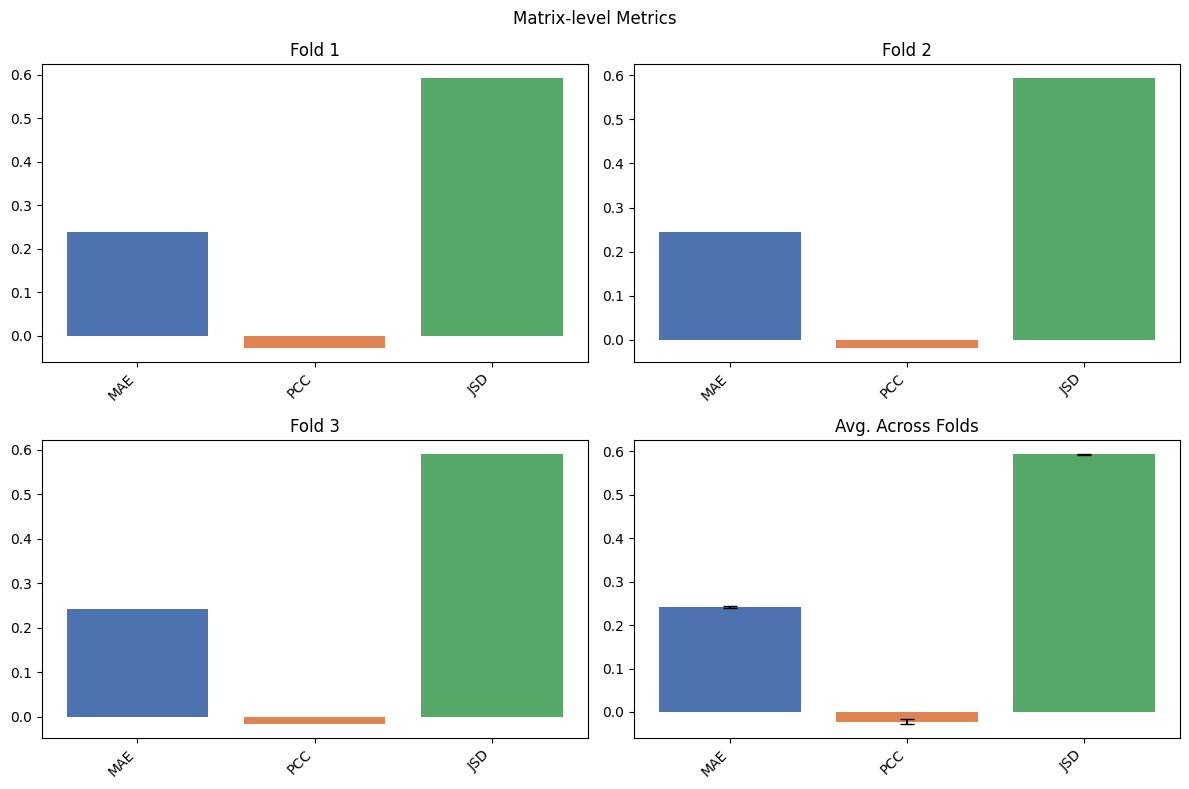

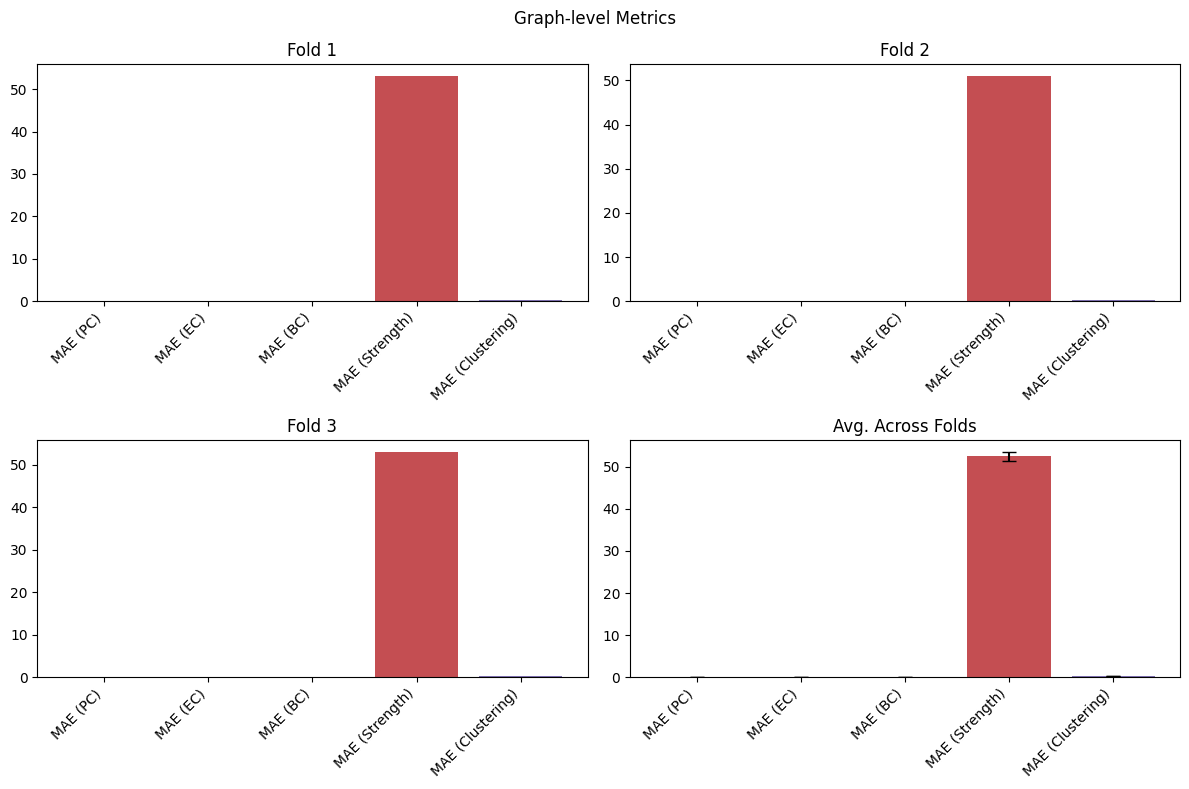

In [11]:
# DenseGCN v3 fold plot (if artifact exists)
dense_gcn_entry = next((e for e in artifact_data if 'dense_gcn_v3' in e['artifact_dir'] and 'ca' not in e['artifact_dir'] and 'gps' not in e['artifact_dir']), None)
if dense_gcn_entry and dense_gcn_entry['folds']:
    fold_results = [f['metrics'] for f in dense_gcn_entry['folds']]
    plot_folds(fold_results, split_if_obscured=True, verbose=False)
else:
    print('DenseGCN v3 artifact not found. Run: python -m src.train_dense_gcn cv --preset v3 --out-dir artifacts/dense_gcn_v3')

### DenseGAT, Bi-SR, GCN+Cross-Attn, GraphGPS, GIN (Failed ~0.47)

**DenseGAT:** 4× GAT blocks, attention + adjacency bias. v5: 2 GCN + 1 GAT. Collapse (PCC=NaN) in v4.

**Bi-SR:** Bipartite graph LR↔HR, message passing for upsampling.

**GCN+Cross-Attn:** GCN encoder, learnable HR queries, cross-attention decoder. PCC ~0.04, Strength MAE 116.

**GraphGPS:** GCN + linear attention block. Val loss ok but Kaggle ~0.48.

**GIN:** Sum aggregation + MLP. Unnormalized adjacency may distort scale.

--- Bi-SR v2 ---


/home/jeet/y4/neurores-gnn/utils/plotting.py:70: RuntimeWarning: Mean of empty slice
  means[k] = float(np.nanmean(vals))
/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


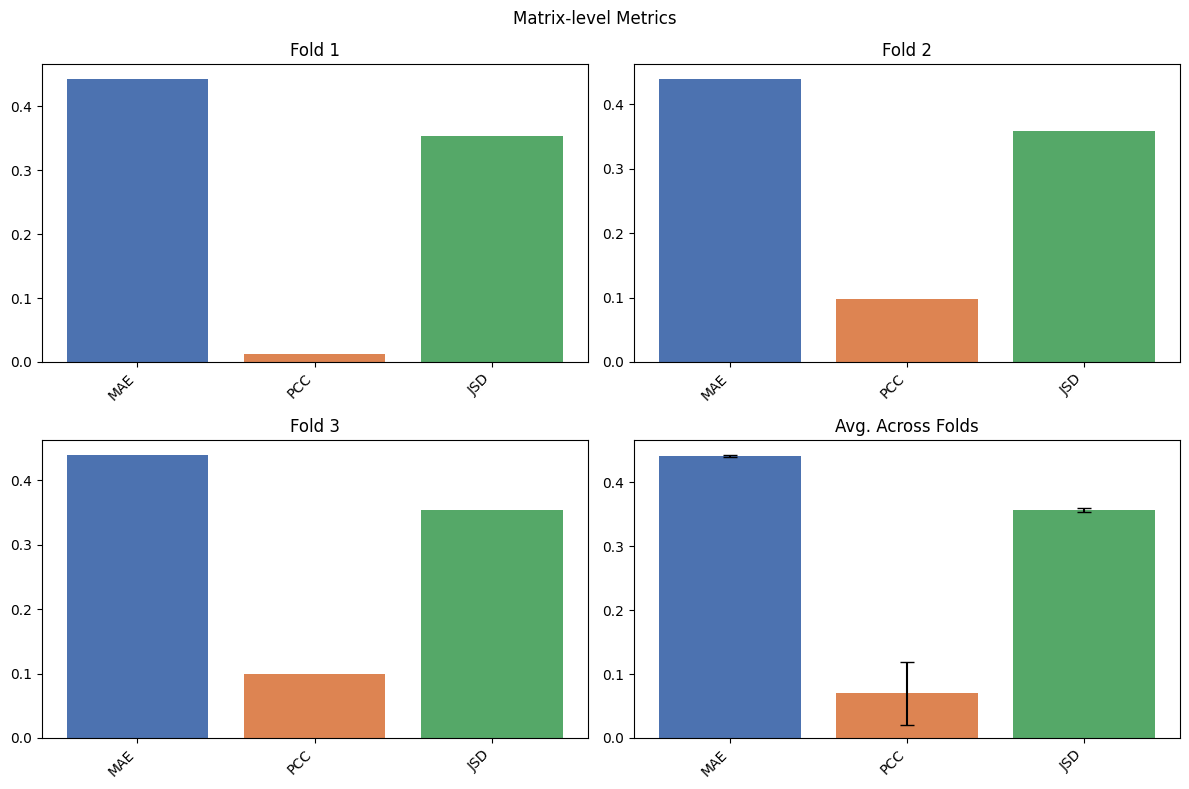

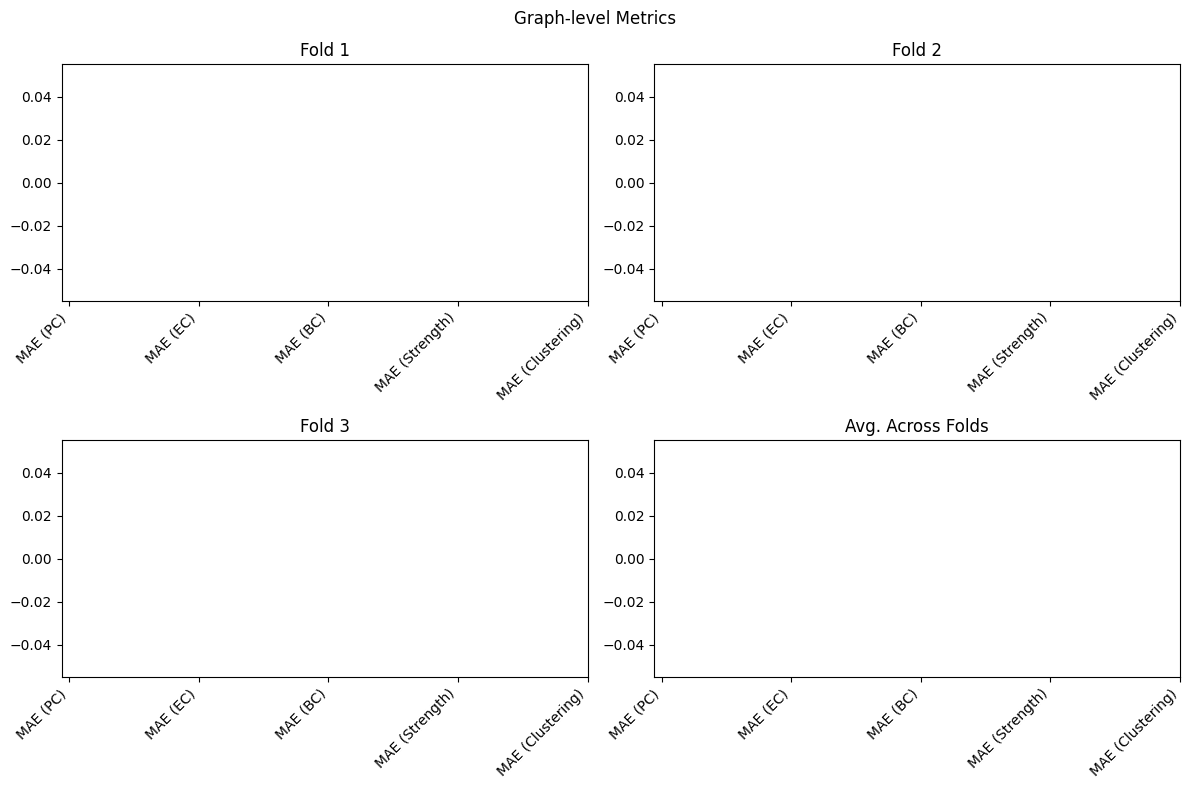

--- DenseGAT v4 ---


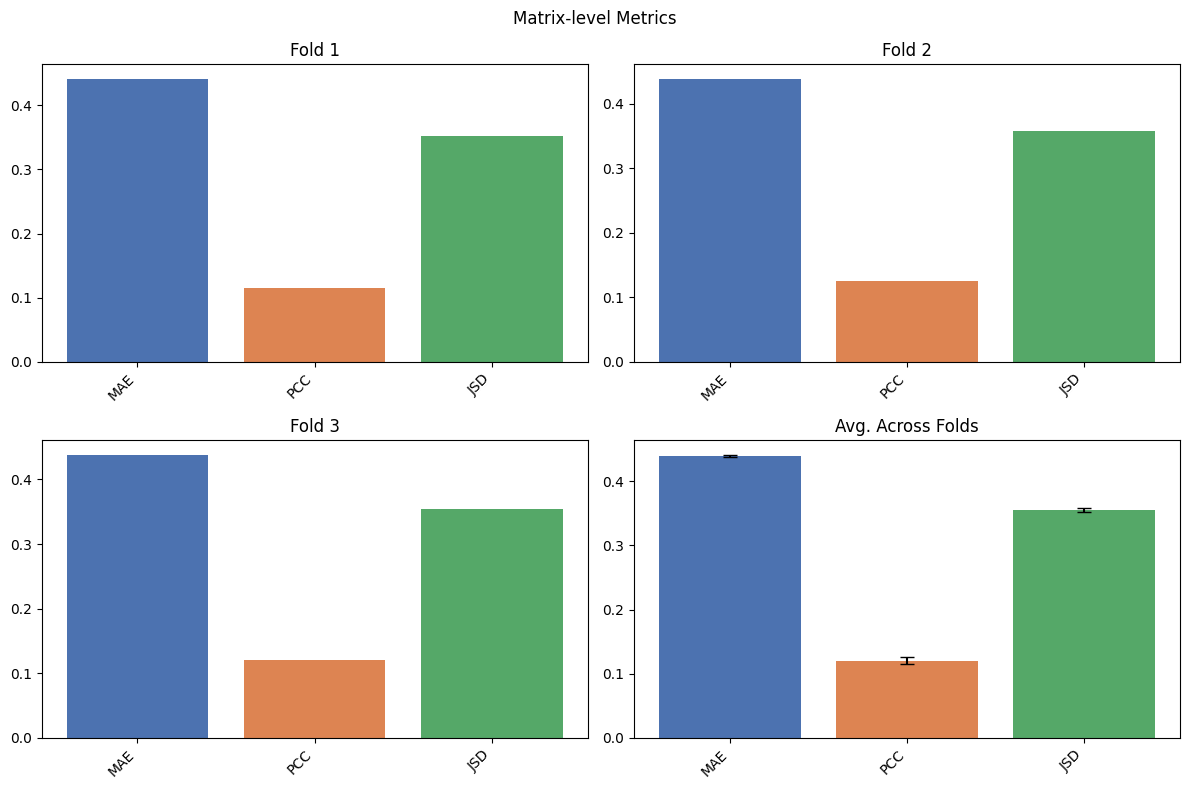

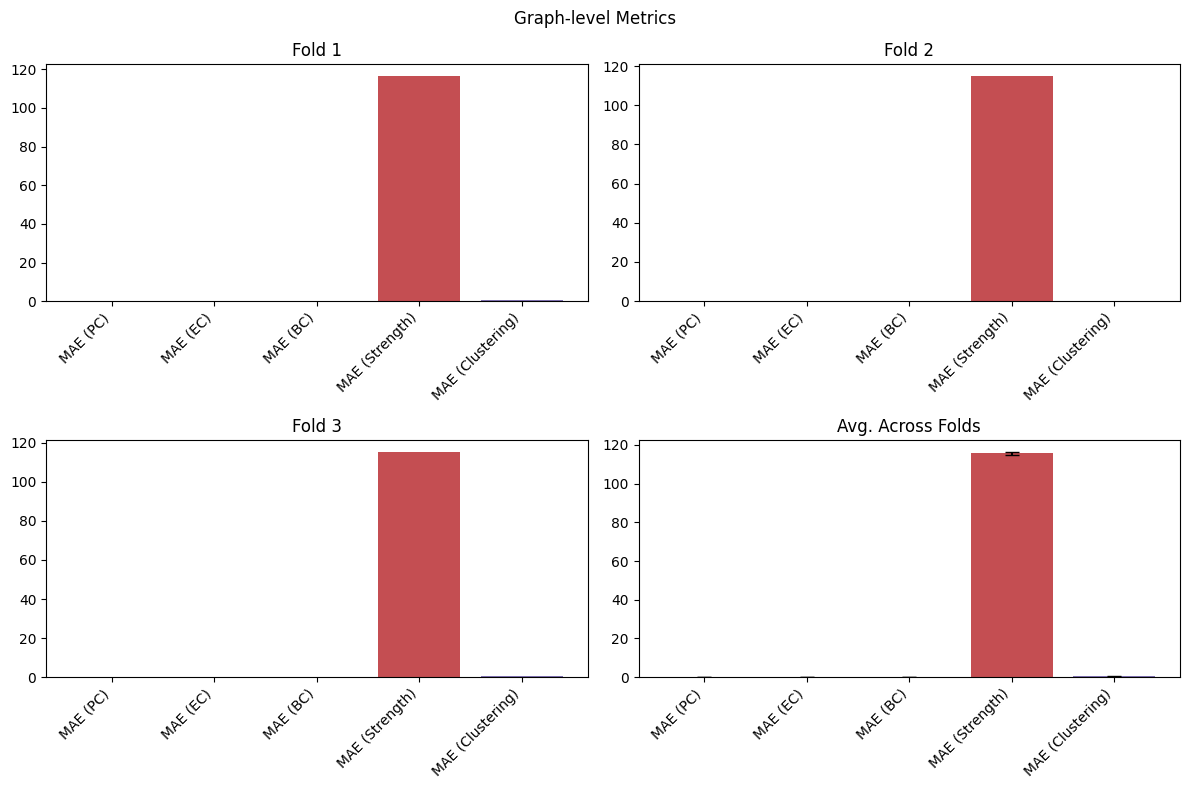

--- DenseGAT v4 test ---


/home/jeet/y4/neurores-gnn/utils/plotting.py:70: RuntimeWarning: Mean of empty slice
  means[k] = float(np.nanmean(vals))
/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


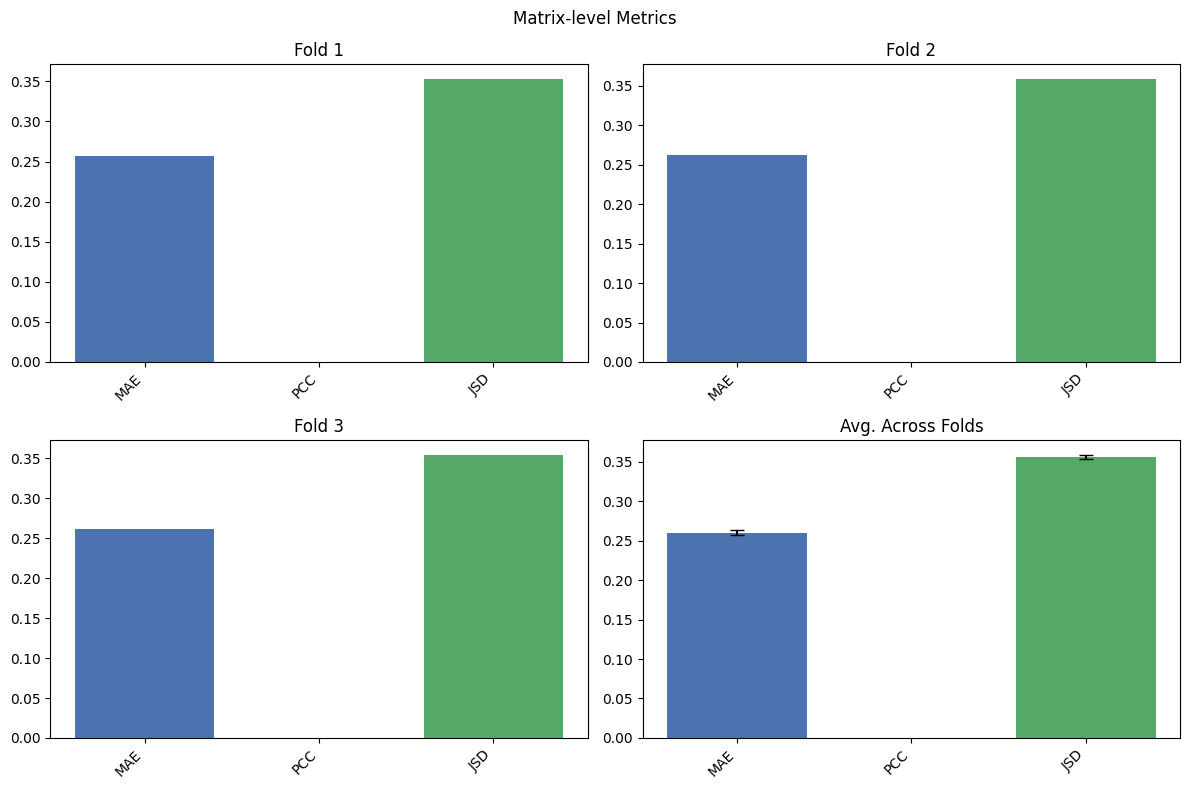

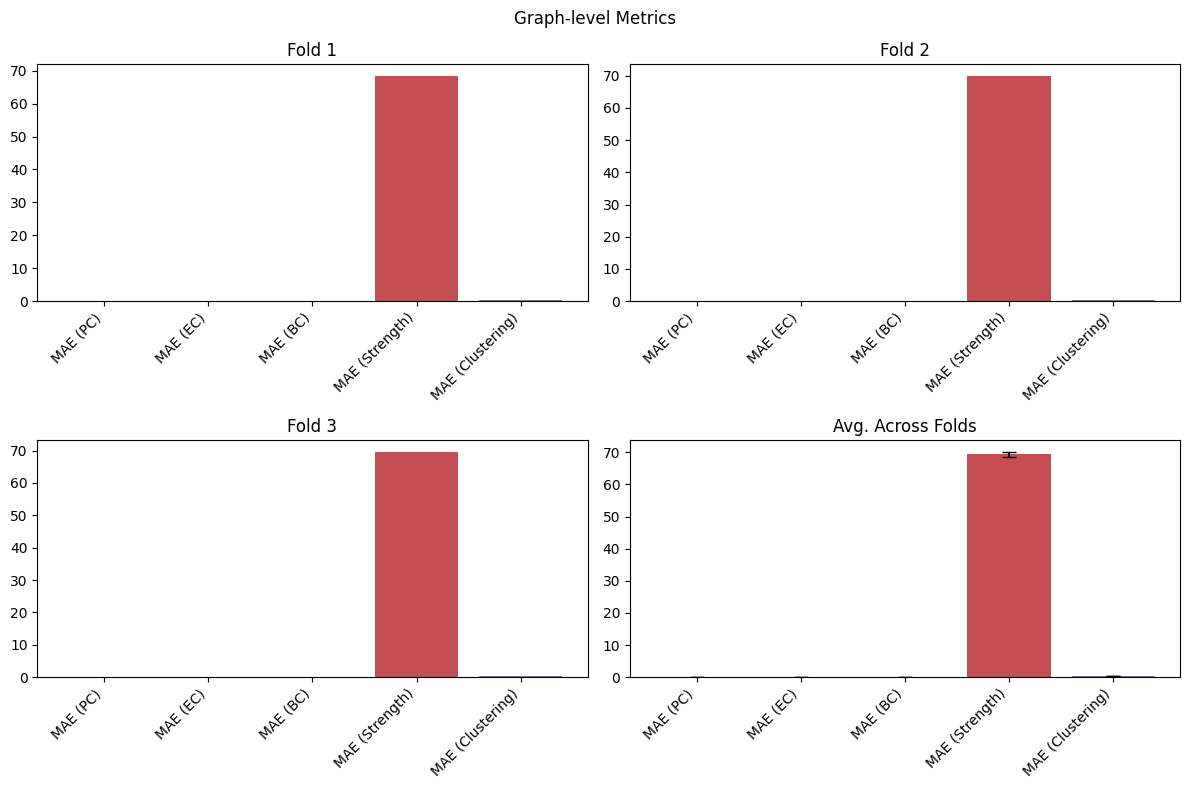

--- DenseGAT v5 ---


/home/jeet/y4/neurores-gnn/utils/plotting.py:70: RuntimeWarning: Mean of empty slice
  means[k] = float(np.nanmean(vals))
/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


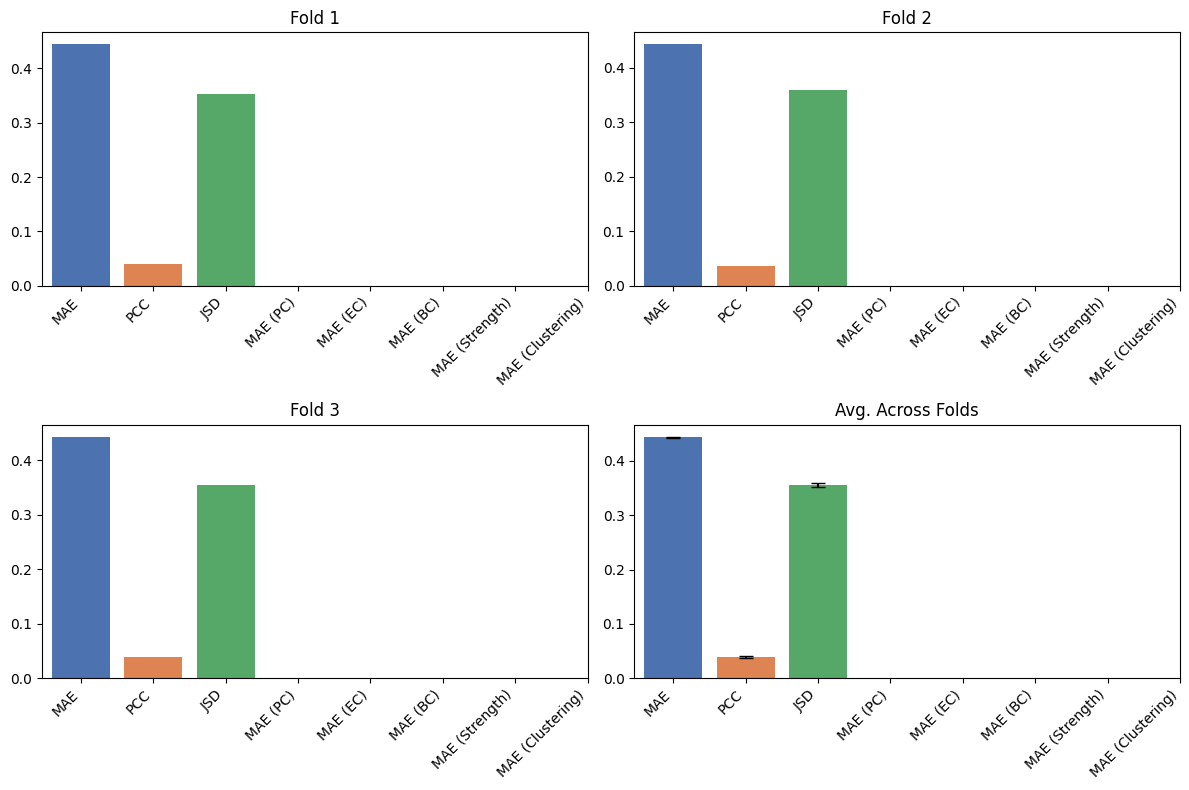

--- GCN+Cross-Attn gcn_ca ---


/home/jeet/y4/neurores-gnn/utils/plotting.py:70: RuntimeWarning: Mean of empty slice
  means[k] = float(np.nanmean(vals))
/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


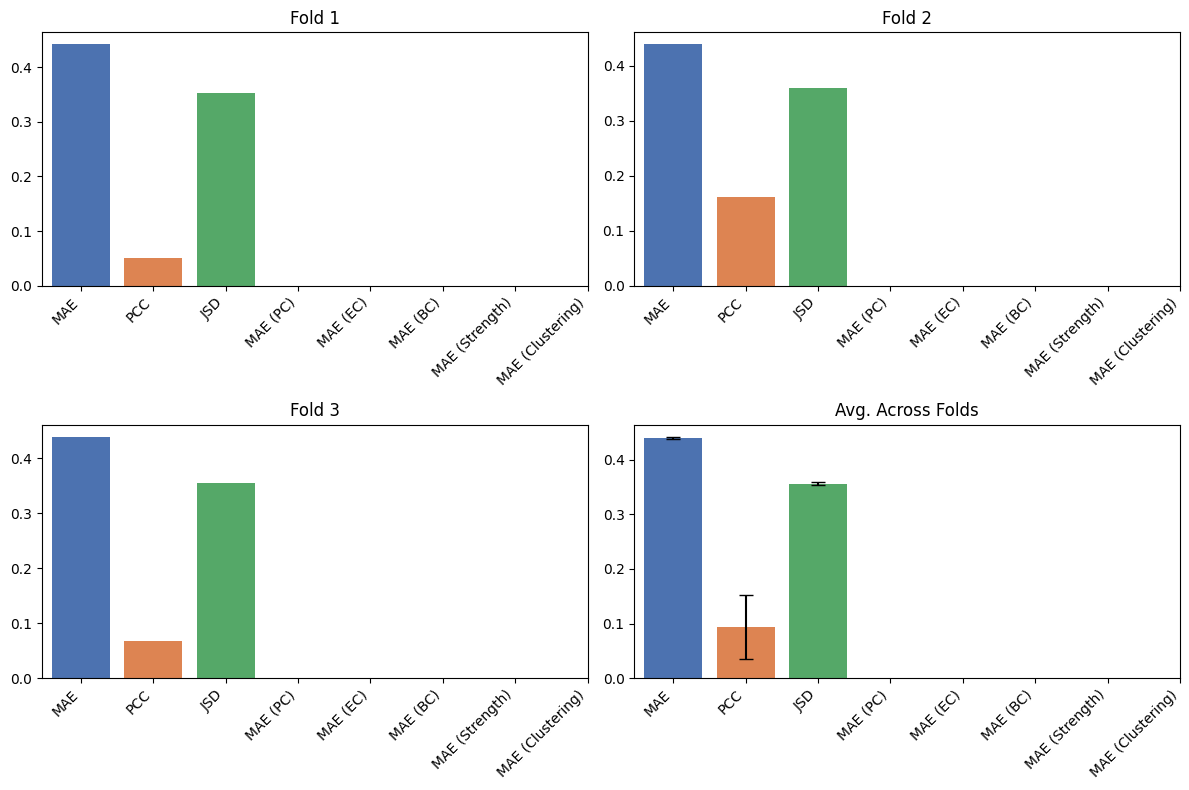

--- GraphGPS gps ---


/home/jeet/y4/neurores-gnn/utils/plotting.py:70: RuntimeWarning: Mean of empty slice
  means[k] = float(np.nanmean(vals))
/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


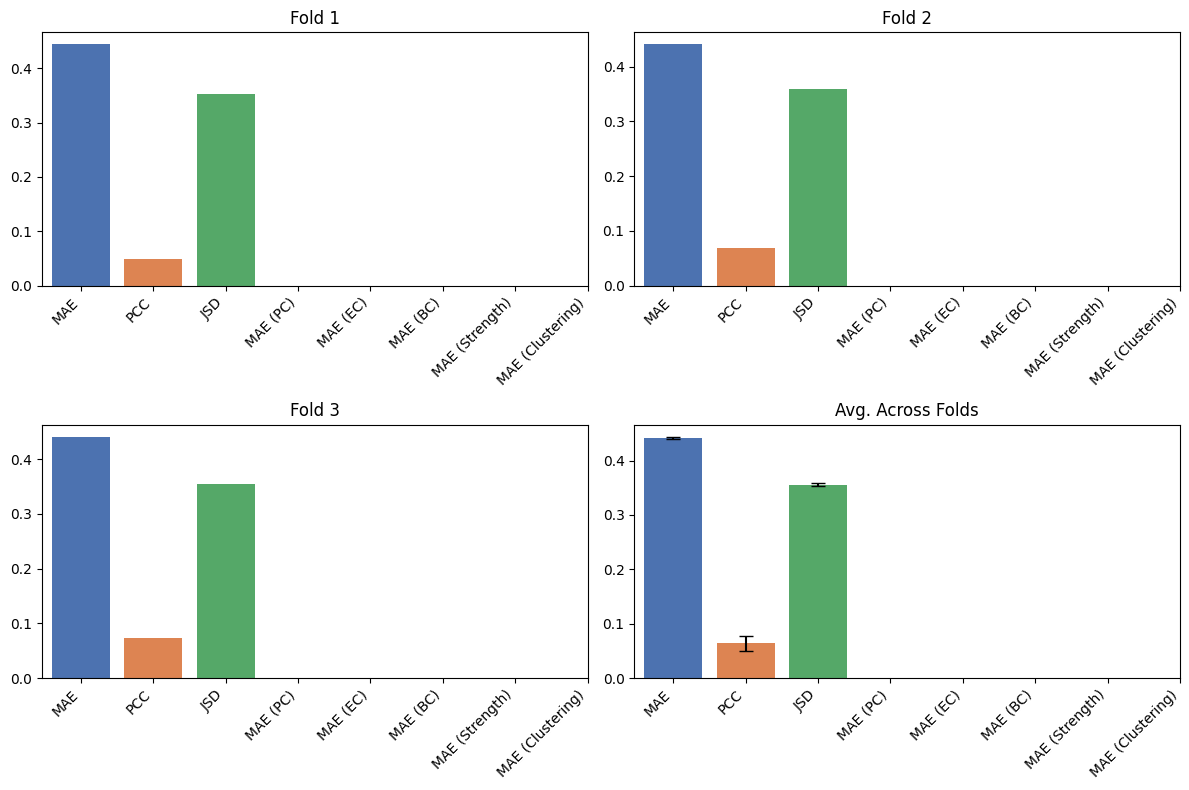

--- dense_gin_quick  ---


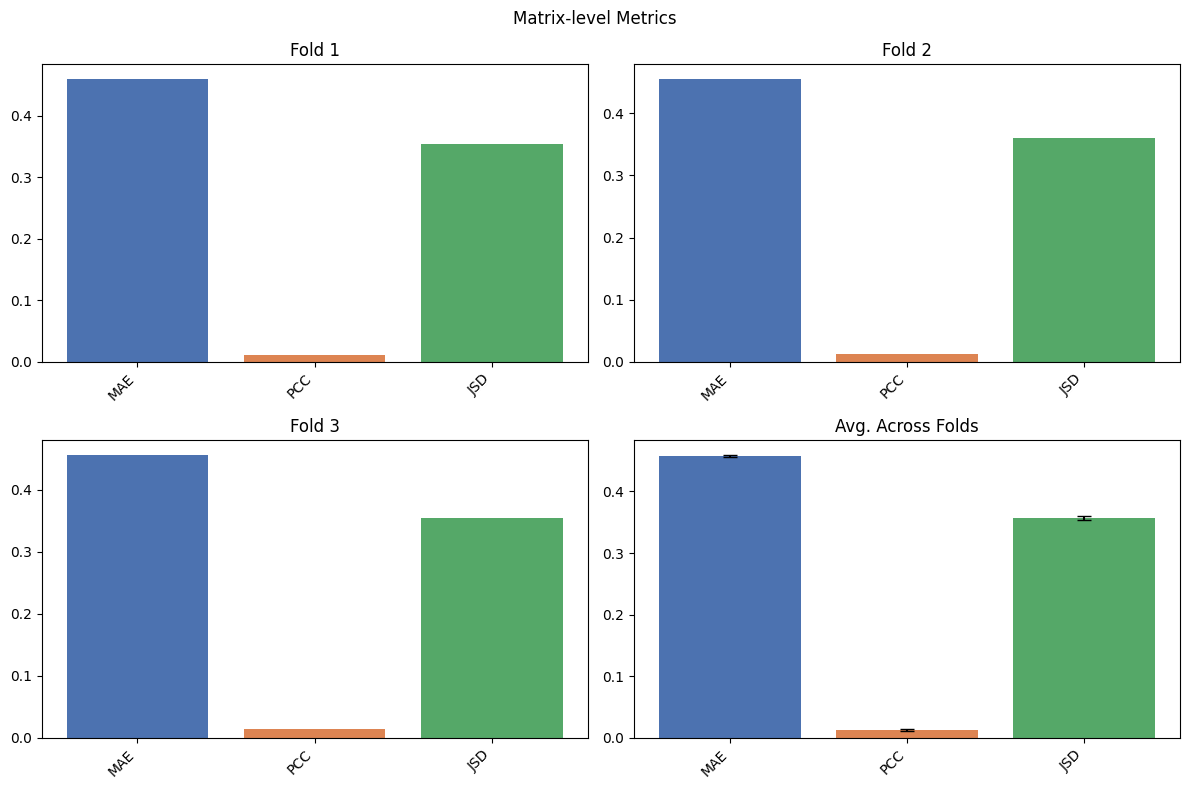

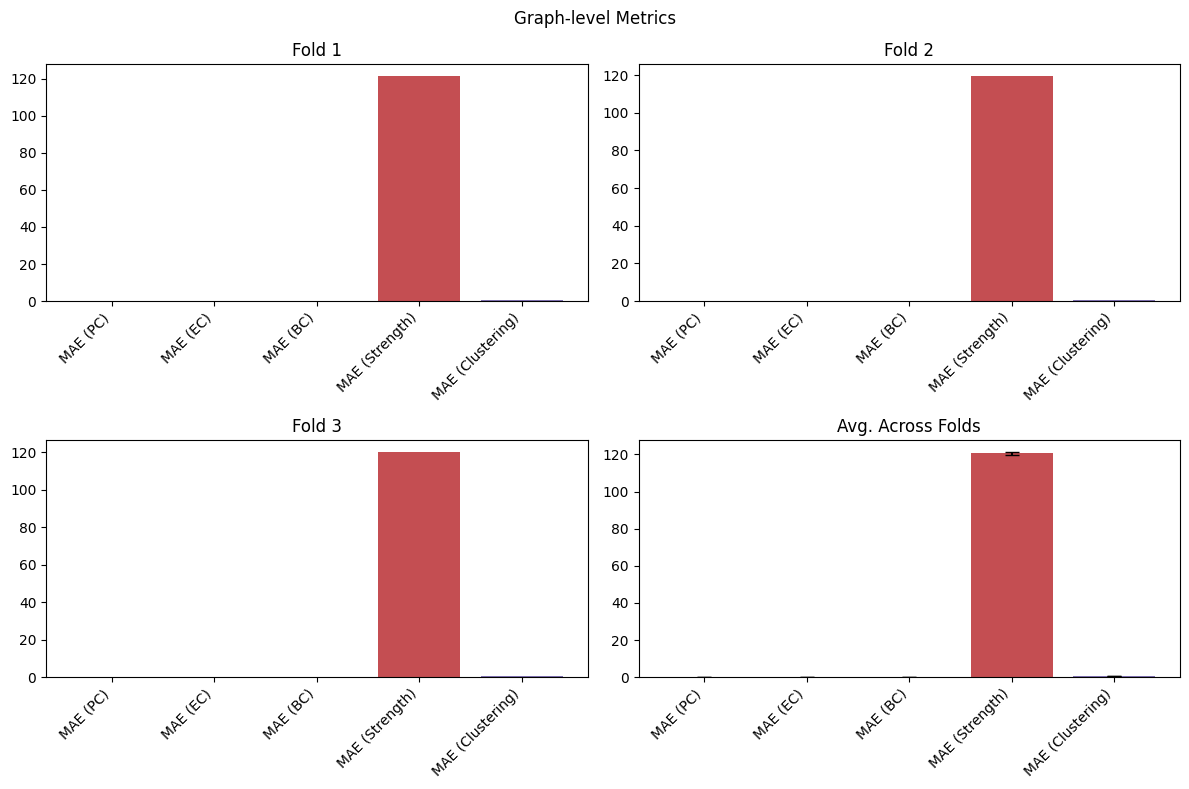

--- GraphSAGE quick ---


/home/jeet/y4/neurores-gnn/utils/plotting.py:70: RuntimeWarning: Mean of empty slice
  means[k] = float(np.nanmean(vals))
/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


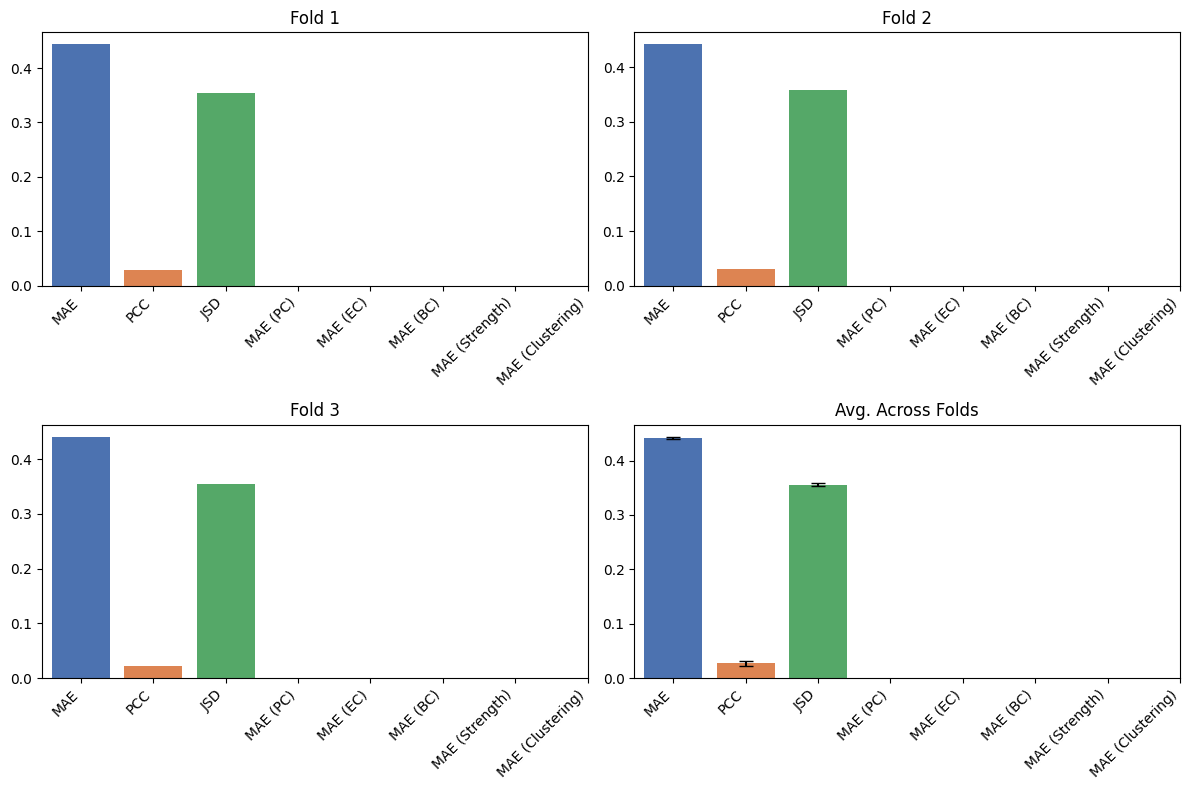

--- test_subsample  ---


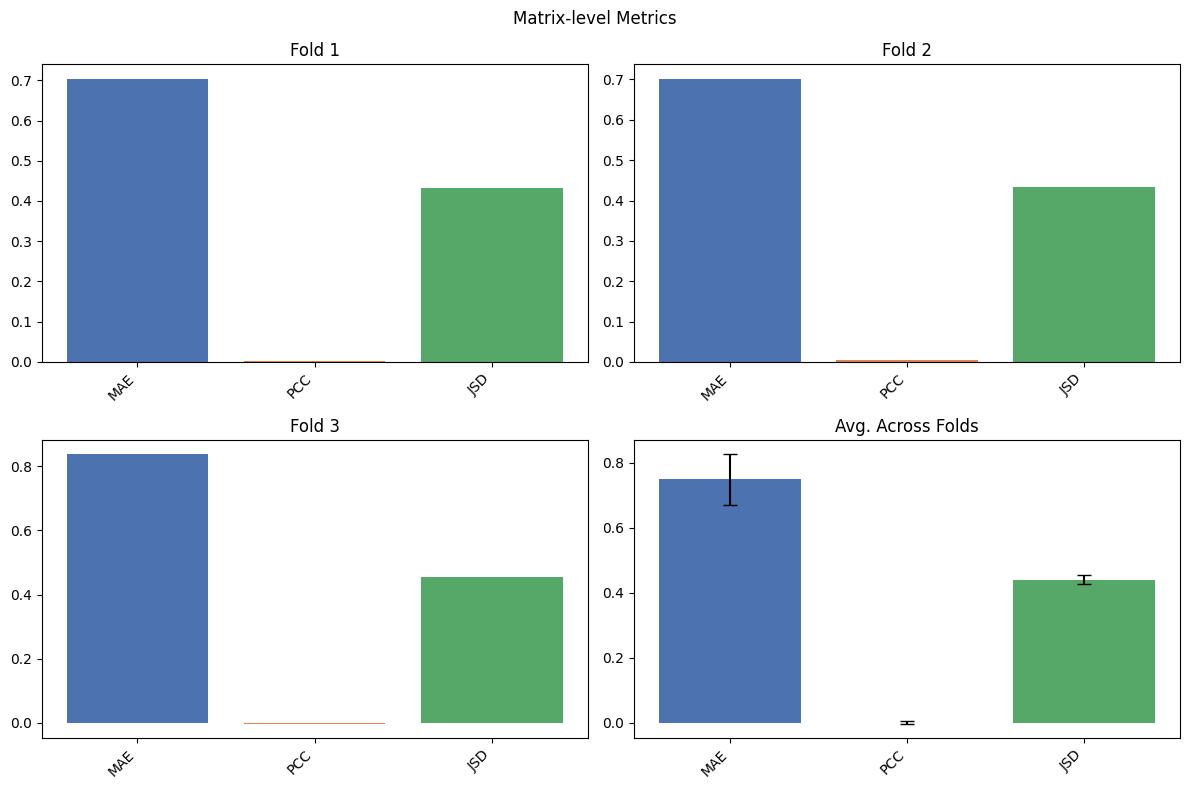

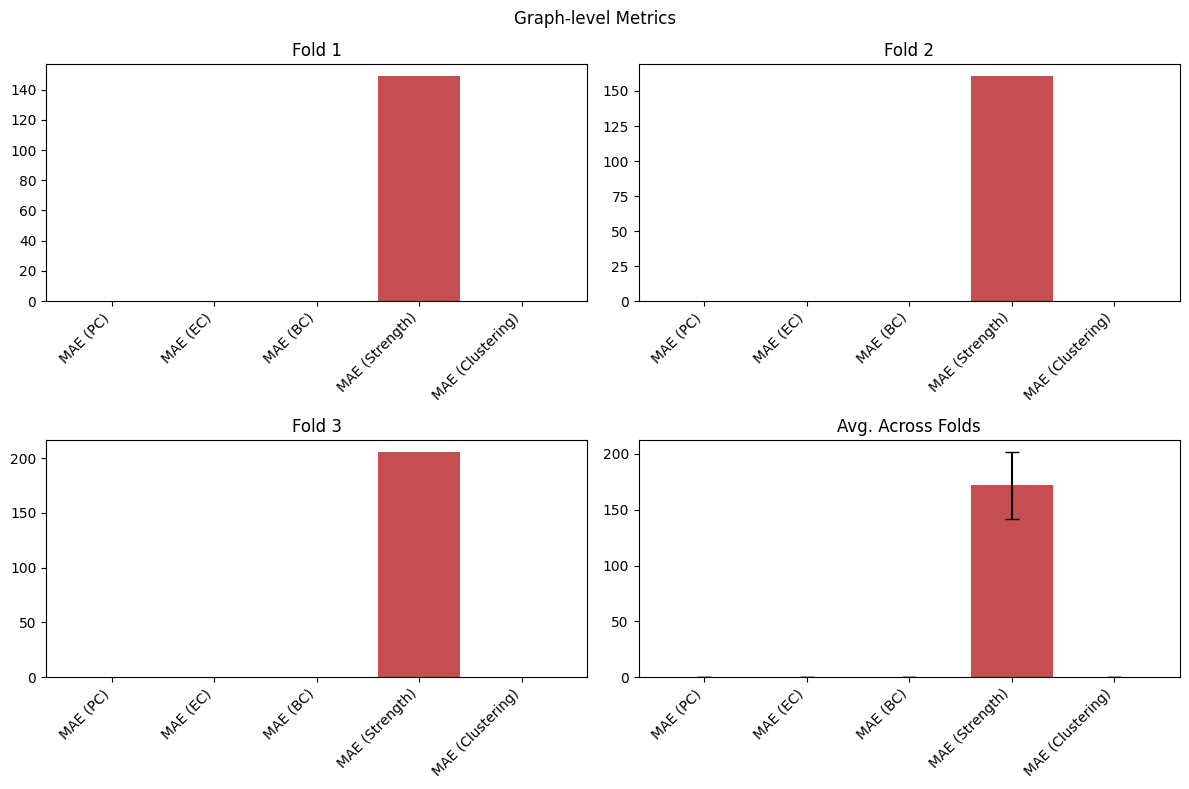

In [12]:
# Plot fold metrics for other models with artifacts
for entry in artifact_data:
    dir_name = entry['artifact_dir']
    if 'dense_gcn_v3' in dir_name and 'ca' not in dir_name and 'gps' not in dir_name:
        continue  # already plotted
    if entry['folds']:
        model, variant = ARTIFACT_TO_MODEL.get(dir_name, (dir_name, ''))
        fold_results = [f['metrics'] for f in entry['folds']]
        print(f'--- {model} {variant} ---')
        plot_folds(fold_results, split_if_obscured=True, verbose=False)

## 4. Learnable Patterns

**What works (DenseGCN v1/v2/v3):**
- **Encoder:** GCN (not GAT) - stable with 167 samples
- **Upsample:** Simple linear 160→268 - complex upsampling (cross-attention, bipartite) fails
- **Decoder:** Bilinear + softplus - conservative init (gain 0.1)
- **Loss:** SmoothL1 - MAE-aligned
- **Regularization:** Dropout 0.35, weight decay 1e-4
- **Early stopping:** Patience 45, val-based

**What fails (GAT, Bi-SR, GCN-CA, GraphGPS, GIN):**
- Attention or bipartite upsampling
- PCC near 0 or Strength MAE 100+
- Val loss can be low while Kaggle is poor - use PCC and graph metrics

## 5. Unexplored Architectures

| Architecture | Effort | Notes |
|--------------|--------|-------|
| **STP-GSR** | High | Primal-dual, edge-space; strong topology |
| **DEFEND** | High | Dual graph, 35k nodes; overfitting risk |
| **Lightweight Edge Decoder** | Medium-High | MLP over edge pairs; sampling needed |
| **GIN (normalized)** | Low | Try GCN-style S instead of A |
| **GraphSAGE** | Low | Implemented; needs full retrain + Kaggle |
| **SGC stabilization** | Low | Different K, init, regularization |

## 6. Overfitting Reduction for Poor Performers (Kaggle MAE > 0.2)

| Strategy | Implementation |
|----------|-----------------|
| **Stronger regularization** | Dropout 0.4–0.5, weight decay 1e-3 |
| **Data augmentation** | Node permutation (preserves structure) |
| **Reduce capacity** | Fewer layers (2), smaller hidden (128) |
| **Conservative decoder** | Xavier gain 0.1, softplus (not clamp) |
| **LR schedule** | ReduceLROnPlateau, lower base LR (5e-4) |
| **Early stopping** | Shorter patience to avoid overfitting |

**Caveat:** GAT, Bi-SR, GCN-CA failed despite fixes. The core issue may be architectural (wrong inductive bias for this task), not just overfitting.